In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import numpy as np
import logging
snscolors = sns.color_palette("colorblind")
from copy import deepcopy

In [2]:
from cosmicfishpie.fishermatrix import cosmicfish
from cosmicfishpie.LSSsurvey import spectro_obs as spobs
from cosmicfishpie.utilities.utils import printing as upr

In [3]:
logger = logging.getLogger("cosmicfishpie.cosmology.nuisance")
logger.setLevel(logging.INFO)

In [4]:
upr.debug = False

In [5]:
upr.debug_print("test")

In [6]:
fiducial = {
    "Omegam": 0.32,
    "Omegab": 0.05,
    "h": 0.67,
    "ns": 0.96,
    "sigma8": 0.815584,
    "w0": -1.0,
    "wa": 0.0,
    "mnu": 0.06,
    "Neff": 3.044,
}
observables = ['GCsp']

In [7]:
options = {
    "accuracy": 1,
    "feedback": 1,
    "code": "symbolic",
    "outroot": "spectro_standard",
    "survey_name": "Euclid",
    "cosmo_model": "LCDM",
    "bfs8terms": False,
}
cosmoFM_A = cosmicfish.FisherMatrix(
    fiducialpars=fiducial,
    options=options,
    observables=observables,
    cosmoModel=options["cosmo_model"],
    surveyName=options["survey_name"],
)

**************************************************************
   _____               _     _____     __  
  / ___/__  ___ __ _  (_)___/ __(_)__ / /  
 / /__/ _ \(_-</  ' \/ / __/ _// (_-</ _ \ 
 \___/\___/___/_/_/_/_/\__/_/ /_/___/_//_/ 

**************************************************************
 This is the new Python version of the CosmicFish code.
**************************************************************
Custom fiducial parameters loaded

  -> Computing cosmology at the fiducial point

  ---> Cosmological functions obtained in:   0.13 s


In [10]:
spectro_Pk_A = spobs.ComputeGalSpectro(cosmoFM_A.fiducialcosmopars,
                                       spectrobiaspars=cosmoFM_A.Spectrobiaspars,
                                       spectrononlinearpars=cosmoFM_A.Spectrononlinpars,
                                       PShotpars=cosmoFM_A.PShotpars,
                                       fiducial_cosmo=cosmoFM_A.fiducialcosmo,
                                       use_bias_funcs=False, configuration=cosmoFM_A)

## Check specs

In [11]:
cosmoFMss = [cosmoFM_A]
for cosmofm in cosmoFMss:
    print(cosmofm.settings['survey_name_spectro'])
    print(cosmofm.settings['outroot'])
    print("Length of freeparams: ", len(cosmofm.freeparams))
    print(cosmofm.freeparams)
# Spectroscopic Power Spectrum

Euclid-Spectroscopic-ISTF-Pessimistic
spectro_standard
Length of freeparams:  13
{'Omegam': 0.01, 'Omegab': 0.01, 'h': 0.01, 'ns': 0.01, 'sigma8': 0.01, 'lnbg_1': 0.0001, 'lnbg_2': 0.0001, 'lnbg_3': 0.0001, 'lnbg_4': 0.0001, 'Ps_1': 0.0001, 'Ps_2': 0.0001, 'Ps_3': 0.0001, 'Ps_4': 0.0001}


# Spectroscopic Power Spectrum

In [12]:
spectros = [spectro_Pk_A]
for spectrosss in spectros:
    print(spectrosss.config.settings['survey_name_spectro'])
    print(spectrosss.config.settings['outroot'])
    print(spectrosss.spectrobiaspars)
    print(spectrosss.spectrononlinearpars)
    print(f"spectrosss.nuisance.sp_bias_model: {spectrosss.nuisance.sp_bias_model}")
    print(f"spectrosss.nuisance.sp_bias_sample: {spectrosss.nuisance.sp_bias_sample}")
    print(f"spectrosss.nuisance.sp_bias_root: {spectrosss.nuisance.sp_bias_root}")
    print("bias term at z=1.2: ", spectrosss.bterm_fid(1.2, k=0.1))
    print("----------------------------------")
    #print(spectrosss.spectrononlinearpars)

Euclid-Spectroscopic-ISTF-Pessimistic
spectro_standard
{'lnbg_1': 0.37944989, 'lnbg_2': 0.4738057, 'lnbg_3': 0.55760176, 'lnbg_4': 0.64125687}
{}
spectrosss.nuisance.sp_bias_model: linear_log
spectrosss.nuisance.sp_bias_sample: g
spectrosss.nuisance.sp_bias_root: lnb
bias term at z=1.2:  1.606094892470849
----------------------------------


In [13]:
zmids = spectro_Pk_A.gcsp_z_bin_mids
zmids

array([1.  , 1.2 , 1.4 , 1.65])

In [15]:
for kii in [0.001, 0.01, 0.1, 1, 5]:
    print("k = ", kii)
    print("A: ", spectro_Pk_A.observed_Pgg(1.0, kii, 1))

k =  0.001
A:  35579.78125979221
k =  0.01
A:  158494.22293264567
k =  0.1
A:  13446.435634226093
k =  1
A:  1.4578267783879542e-10
k =  5
A:  3.329905367714045e-271


#### Compute the observed power spectrum at different redshifts and different angles 

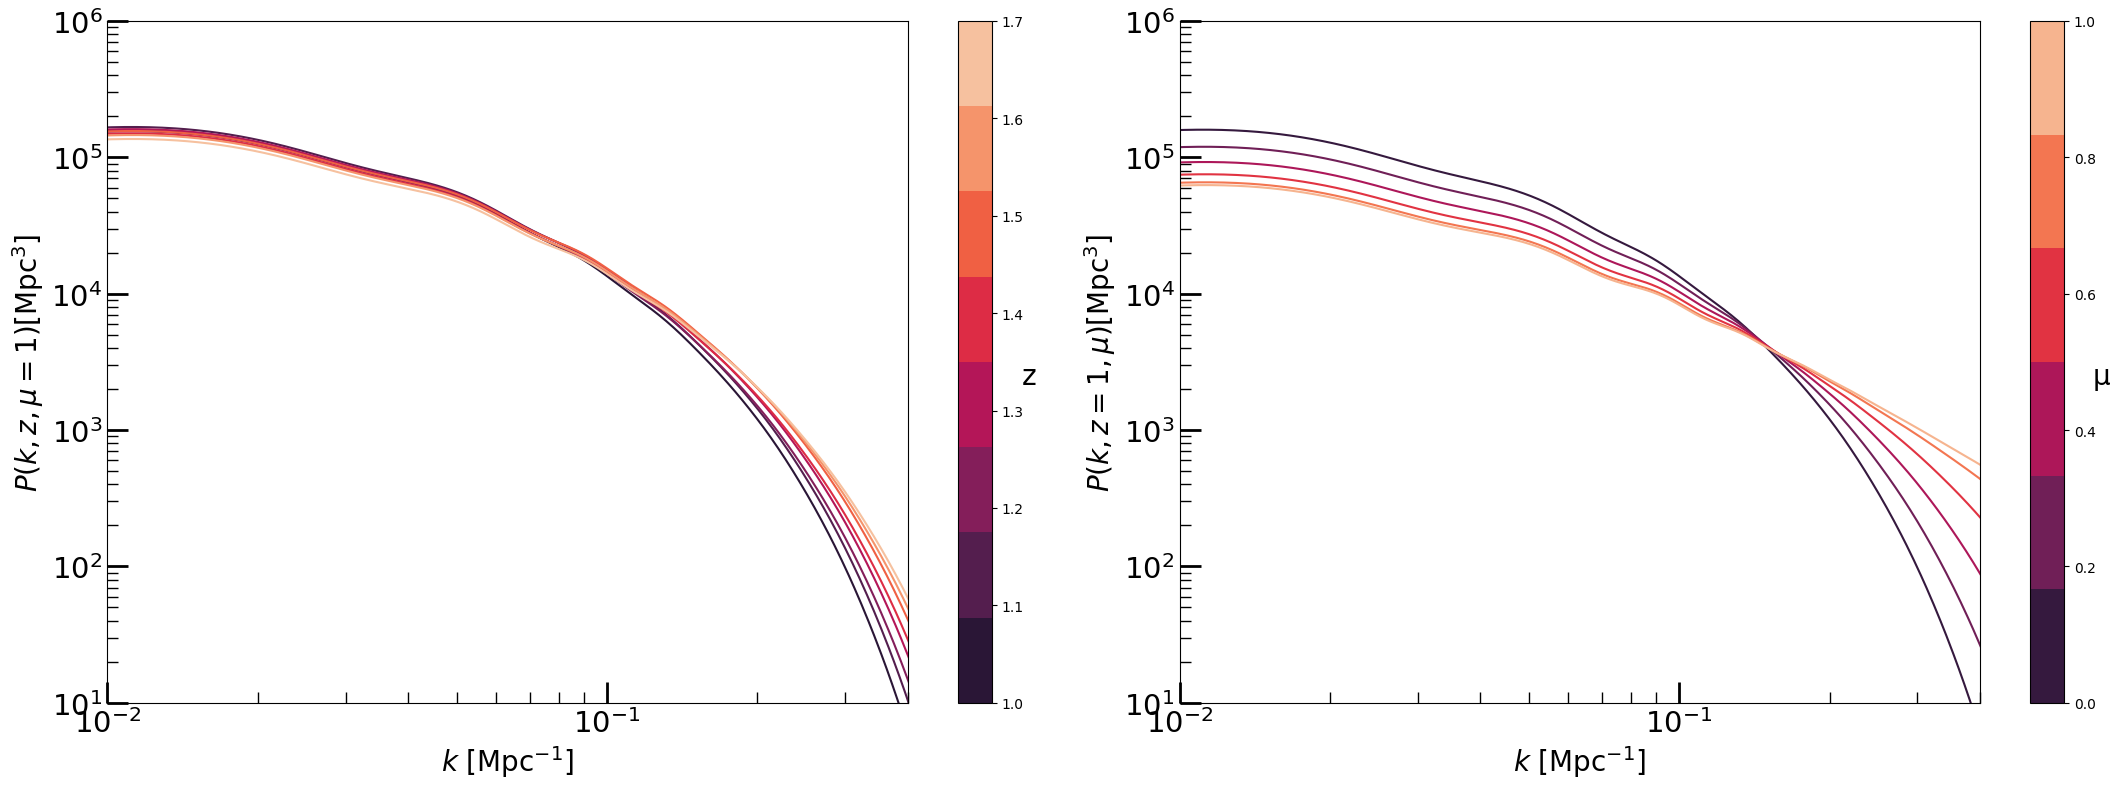

In [16]:

fig, axs = plt.subplots(1, 2, figsize=(22, 8))  # Increased width to accommodate colorbars
kk = spectro_Pk_A.k_grid
# First subplot
colormap_z = sns.color_palette("rocket", 8)
colors_z = iter(colormap_z)
zz = np.linspace(1, 1.7, 8)

sm_z = plt.cm.ScalarMappable(cmap=ListedColormap(colormap_z), norm=plt.Normalize(vmin=zz.min(), vmax=zz.max()))
sm_z.set_array([])

for z in zz:
    c = next(colors_z)
    axs[0].loglog(kk, spectro_Pk_A.observed_Pgg(z, kk, 1), c=c)

axs[0].set_xlabel(r"$k$ [$\mathrm{Mpc}^{-1}$]", fontsize=20)
axs[0].set_ylabel(r"$P(k,z,\mu=1)[\mathrm{Mpc}^3]$", fontsize=20)
axs[0].set_xlim([1e-2, 0.4])
axs[0].set_ylim([1e1, 1e6])
axs[0].set_xscale("log")

cbar_z = fig.colorbar(sm_z, ax=axs[0])
cbar_z.set_label('z', fontsize=20, rotation=0)

# Second subplot
colormap_mu = sns.color_palette("rocket", 6)
colors_mu = iter(colormap_mu)
mus = np.linspace(1, 0, 6)

sm_mu = plt.cm.ScalarMappable(cmap=ListedColormap(colormap_mu), norm=plt.Normalize(vmin=mus.min(), vmax=mus.max()))
sm_mu.set_array([])

for mu in mus:
    c = next(colors_mu)
    axs[1].loglog(kk, spectro_Pk_A.observed_Pgg(1, kk, mu), c=c)

axs[1].set_xlabel(r"$k$ [$\mathrm{Mpc}^{-1}$]", fontsize=20)
axs[1].set_ylabel(r"$P(k,z=1,\mu)[\mathrm{Mpc}^3]$", fontsize=20)
axs[1].set_xlim([1e-2, 0.4])
axs[1].set_ylim([1e1, 1e6])
cbar_mu = fig.colorbar(sm_mu, ax=axs[1])
cbar_mu.set_label('μ', fontsize=20, rotation=0)

# Tick parameters
[ax.tick_params(which="major", length=15, width=2, direction="in") for ax in axs]
[ax.tick_params(which="minor", length=8, width=1, direction="in") for ax in axs]
[ax.minorticks_on() for ax in axs]
[ax.tick_params(axis="both", which="major", labelsize=21) for ax in axs]
[ax.tick_params(axis="both", which="minor", labelsize=15) for ax in axs]

plt.tight_layout()
plt.show()

In [18]:
Cparams= deepcopy(cosmoFM_A.fiducialcosmopars)
Cparams['Omegam'] = 0.31
Cparams['h'] = 0.68

In [19]:
spectro_Pk_C = spobs.ComputeGalSpectro(Cparams,
                                       spectrobiaspars=cosmoFM_A.Spectrobiaspars,
                                       spectrononlinearpars=cosmoFM_A.Spectrononlinpars,
                                       PShotpars=cosmoFM_A.PShotpars,
                                       fiducial_cosmo=cosmoFM_A.fiducialcosmo,
                                       use_bias_funcs=False, configuration=cosmoFM_A)

### Compare the Power Spectrum from two different cosmologies

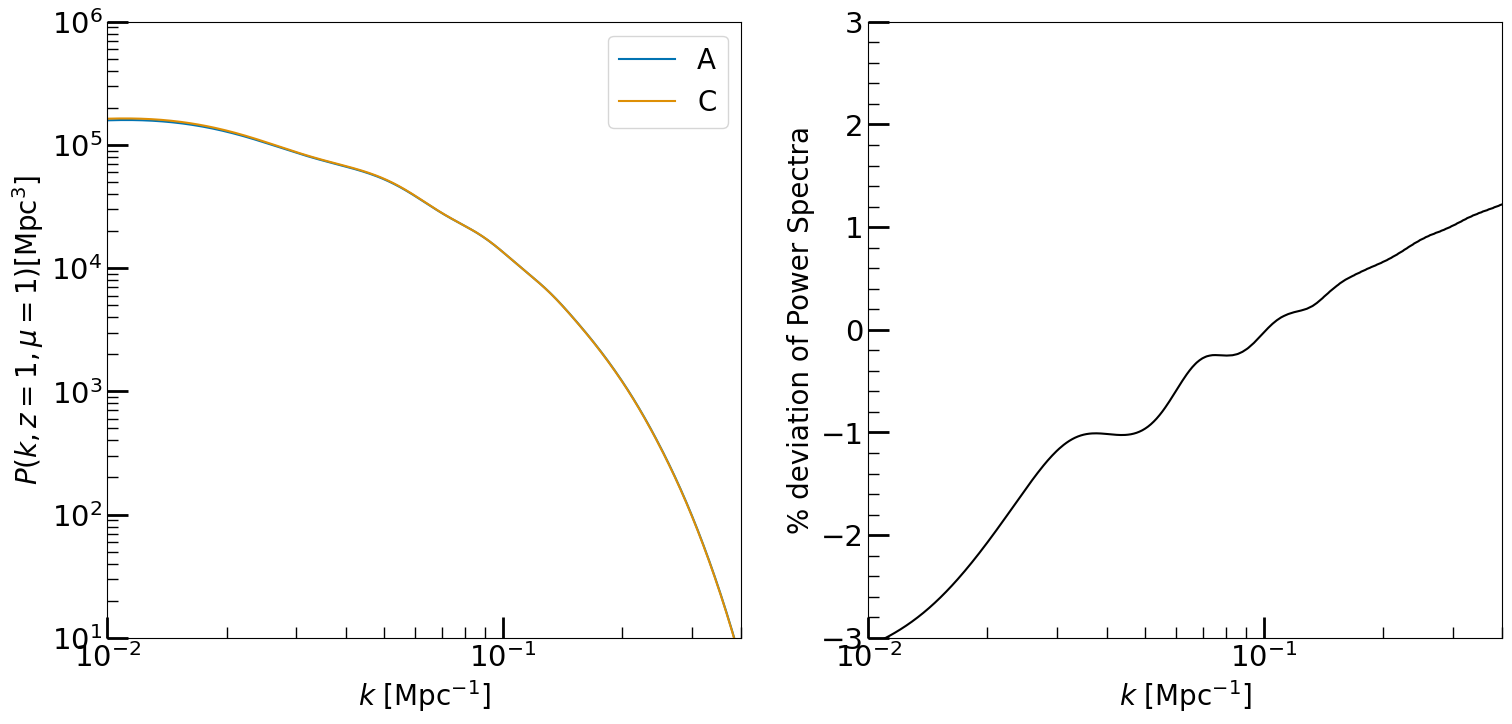

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(18, 8))

colormap = sns.color_palette("colorblind")
colors = iter(colormap)
zz = 1.0
muu = 1.0
spectro_1 = spectro_Pk_A
label_1 = "A"
spectro_2 = spectro_Pk_C
label_2 = "C"

c = next(colors)
axs[0].loglog(kk, spectro_1.observed_Pgg(zz, kk, muu), c=c, label=label_1)

c = next(colors)
axs[0].loglog(kk, spectro_2.observed_Pgg(zz, kk, muu), c=c, label=label_2)

axs[0].set_xlabel(r"$k$ [$\mathrm{Mpc}^{-1}$]", fontsize=20)
axs[0].set_ylabel(r"$P(k,z=1,\mu=1)[\mathrm{Mpc}^3]$", fontsize=20)
axs[0].set_xlim([1e-2, 0.4])
axs[0].set_ylim([1e1, 1e6])
axs[0].legend(fontsize=20)
axs[0].set_xscale("log")

axs[1].plot(
    kk,
    ((spectro_1.observed_Pgg(zz, kk, muu) - spectro_2.observed_Pgg(zz, kk, muu))
    / spectro_1.observed_Pgg(zz, kk, muu))
    * 100,
    c="black",
)

axs[1].set_xlabel(r"$k$ [$\mathrm{Mpc}^{-1}$]", fontsize=20)
axs[1].set_ylabel(r"% deviation of Power Spectra", fontsize=20)
axs[1].set_xlim([1e-2, 0.4])
axs[1].set_ylim([-3, 3])
axs[1].set_xscale("log")

[ax.tick_params(which="major", length=15, width=2, direction="in") for ax in axs]
[ax.tick_params(which="minor", length=8, width=1, direction="in") for ax in axs]
[ax.minorticks_on() for ax in axs]
[ax.tick_params(axis="both", which="major", labelsize=21) for ax in axs]
[ax.tick_params(axis="both", which="minor", labelsize=15) for ax in axs]

plt.show()

In [31]:

spectro_Pk_C.k_grid


array([1.00000000e-03, 1.00836046e-03, 1.01679081e-03, ...,
       4.91743232e+00, 4.95854430e+00, 5.00000000e+00])

In [34]:
import numpy as np
from scipy.integrate import simpson
from cosmicfishpie.LSSsurvey import spectro_obs as spobs

def compute_chi2_and_likelihood(fiducial_spectro, test_spectro):
    # Initialize chi-square
    chi2 = 0.0
    
    # Get z and mu bins
    z_bins = fiducial_spectro.gcsp_z_bin_mids
    mu_bins = np.linspace(0, 1, 10)  # Adjust the number of mu bins as needed
    k_bins = np.logspace(-3, 0.25, 100)
    
    # Create meshgrid for vectorized computation
    k_mesh, mu_mesh = np.meshgrid(k_bins, mu_bins, indexing='ij')
    
    # Loop over redshift bins
    for z in z_bins:
        # Compute observed P(k) for fiducial and test parameters
        P_fid = fiducial_spectro.observed_Pgg(z, k_mesh, mu_mesh)
        P_test = test_spectro.observed_Pgg(z, k_mesh, mu_mesh)
        
        # Compute integrand
        integrand = (
            k_mesh**2 / (8 * np.pi**2) *
            (P_test - P_fid)**2 / P_test**2
        )
        #print(integrand)
        # Integrate over k and mu
        chi2_of_z = simpson(simpson(integrand, x=mu_bins, axis=1), x=k_bins)
        
        # Add contribution from this redshift bin
        chi2 += chi2_of_z
    
    # Compute likelihood
    log_likelihood = -0.5 * chi2
    
    return chi2, log_likelihood

# Example usage
fiducial_params = cosmoFM_A.fiducialcosmopars
test_params = fiducial_params.copy()
test_params['Omegam'] += 0.1  # Slightly modify a parameter

# Create spectro objects for fiducial and test cosmologies
fiducial_spectro = spobs.ComputeGalSpectro(fiducial_params,
                                           spectrobiaspars=cosmoFM_A.Spectrobiaspars,
                                           spectrononlinearpars=cosmoFM_A.Spectrononlinpars,
                                           PShotpars=cosmoFM_A.PShotpars,
                                           fiducial_cosmo=cosmoFM_A.fiducialcosmo,
                                           use_bias_funcs=False, configuration=cosmoFM_A)

test_spectro = spobs.ComputeGalSpectro(test_params,
                                       spectrobiaspars=cosmoFM_A.Spectrobiaspars,
                                       spectrononlinearpars=cosmoFM_A.Spectrononlinpars,
                                       PShotpars=cosmoFM_A.PShotpars,
                                       fiducial_cosmo=cosmoFM_A.fiducialcosmo,
                                       use_bias_funcs=False, configuration=cosmoFM_A)

chi2, log_likelihood = compute_chi2_and_likelihood(fiducial_spectro, test_spectro)

print(f"Chi-square: {chi2}")
print(f"Log-likelihood: {log_likelihood}")

Chi-square: 0.0009844480684513158
Log-likelihood: -0.0004922240342256579
